In [1]:
# Task 3: Feature Engineering & Preprocessing Pipeline

print("Feature Engineering & Preprocessing Pipeline")
print("RabTech Academy Internship")

Feature Engineering & Preprocessing Pipeline
RabTech Academy Internship


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load Titanic dataset

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Shape:")
print(df.shape)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing Values:
survived         0
pclass           

In [6]:
# Select useful features

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "class",
    "who",
    "alone"
]

X = df[features]
y = df["survived"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   pclass     sex   age  sibsp  parch     fare embarked  class    who  alone
0       3    male  22.0      1      0   7.2500        S  Third    man  False
1       1  female  38.0      1      0  71.2833        C  First  woman  False
2       3  female  26.0      0      0   7.9250        S  Third  woman   True
3       1  female  35.0      1      0  53.1000        S  First  woman  False
4       3    male  35.0      0      0   8.0500        S  Third    man   True

Target:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [7]:
# Split data before any preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 10)
Testing data: (179, 10)


In [8]:
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "alone"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical Features:
['sex', 'embarked', 'class', 'who', 'alone']


In [9]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [10]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [13]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

print("Complete ML pipeline created.")

Complete ML pipeline created.


In [14]:
# Train only using training data

model_pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [15]:
# Predict test data

y_pred = model_pipeline.predict(X_test)

print("Predictions completed!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed!
First 10 predictions:
[0 0 0 0 1 0 1 1 0 0]


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 82.12 %


In [17]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



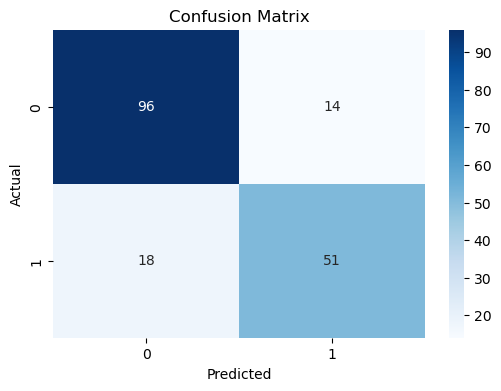

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Get the trained preprocessing pipeline

trained_preprocessor = model_pipeline.named_steps["preprocessor"]

feature_names = trained_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

Number of processed features: 18

Feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S' 'cat__class_First' 'cat__class_Second'
 'cat__class_Third' 'cat__who_child' 'cat__who_man' 'cat__who_woman'
 'cat__alone_False' 'cat__alone_True']


In [20]:
# Get Random Forest feature importance

model = model_pipeline.named_steps["model"]

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,num__fare,0.233576
1,num__age,0.219361
5,cat__sex_female,0.092185
6,cat__sex_male,0.086909
14,cat__who_man,0.084181
0,num__pclass,0.050041
15,cat__who_woman,0.043544
2,num__sibsp,0.033736
12,cat__class_Third,0.031130
3,num__parch,0.028382


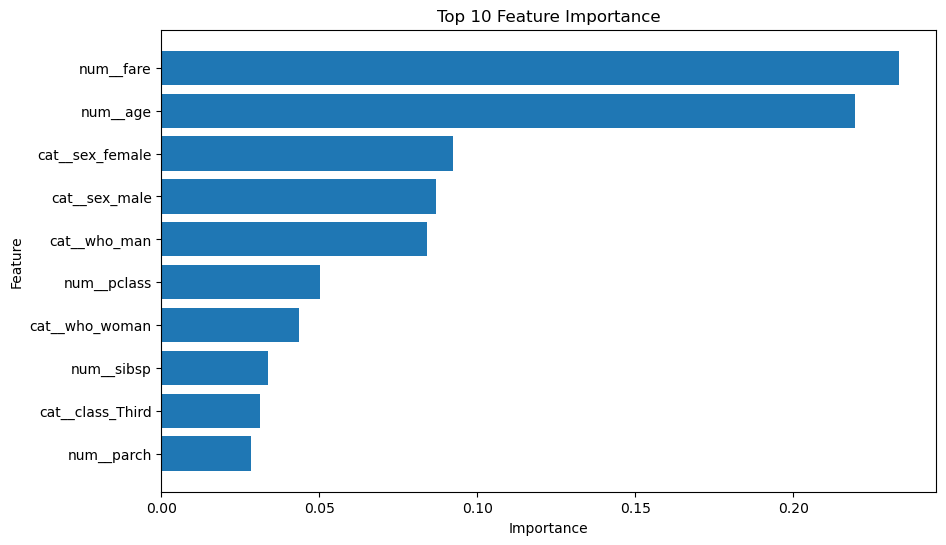

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()

plt.show()

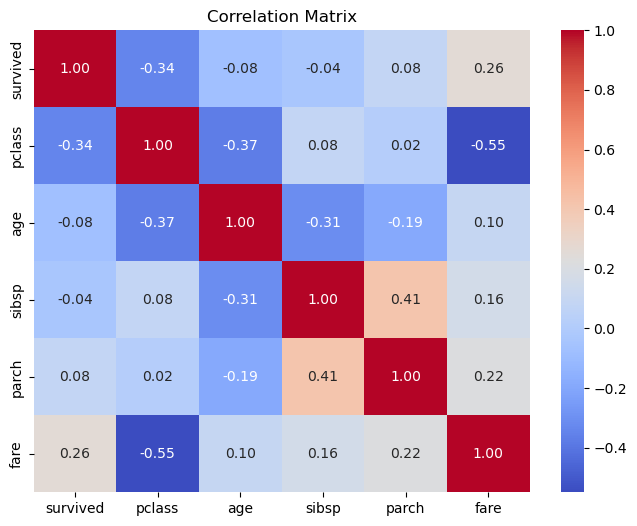

In [22]:
correlation_data = df[
    ["survived", "pclass", "age", "sibsp", "parch", "fare"]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()